# Week 4 - Noise Sensitivity Analysis

## Gaussian Noise Injection

In [3]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [4]:
df = pd.read_csv("../data/cleaned_ai4i.csv")

print(df.shape)
df.head()

(10000, 15)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_enc
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,2
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1


In [5]:
target = "Machine failure"

drop_cols = [
    "UDI",
    "Product ID",
    "Type",
    target
]

X = df.drop(columns=drop_cols, errors="ignore")
y = df[target]

print(X.shape)
print(X.dtypes)

(10000, 11)
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Type_enc                     int64
dtype: object


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (8000, 11)
Test set: (2000, 11)

Training class distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test class distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [7]:
def inject_noise(X_test, noise_level):

    X_noisy = X_test.copy()

    numeric_cols = X_noisy.select_dtypes(include=[np.number]).columns

    # Convert numeric columns to float
    X_noisy[numeric_cols] = X_noisy[numeric_cols].astype(float)

    noise = np.random.normal(
        loc=0,
        scale=noise_level,
        size=X_noisy[numeric_cols].shape
    )

    X_noisy.loc[:, numeric_cols] += noise

    return X_noisy

In [8]:
X_noise = inject_noise(X_test,0.05)

print(X_noise.head())

      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
2997           300.404737               309.734559             1345.006657   
4871           303.746609               312.406685             1513.009729   
3858           302.407857               311.323500             1559.008261   
951            295.548231               306.275439             1508.979682   
6463           300.538772               309.979258             1358.015421   

      Torque [Nm]  Tool wear [min]       TWF       HDF       PWF       OSF  \
2997    62.689968       153.079916  0.004191  0.043198  0.016263  0.078525   
4871    40.087466       134.941029 -0.039034  0.039806 -0.010532  0.000781   
3858    37.552906       209.005544 -0.066442  0.035165  0.016822 -0.032425   
951     35.847305        59.884803  0.066506 -0.040071  0.077533 -0.011821   
6463    60.410060       101.928492  0.095691 -0.050992 -0.056721 -0.023255   

           RNF  Type_enc  
2997  0.048680  1.069098  
4871  0.

In [9]:
print("Original Test Data:")
print(X_test.head())

print("\nNoisy Test Data:")
print(X_noise.head())

Original Test Data:
      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
2997                300.5                    309.8                    1345   
4871                303.7                    312.4                    1513   
3858                302.5                    311.4                    1559   
951                 295.6                    306.3                    1509   
6463                300.5                    310.0                    1358   

      Torque [Nm]  Tool wear [min]  TWF  HDF  PWF  OSF  RNF  Type_enc  
2997         62.7              153    0    0    0    0    0         1  
4871         40.1              135    0    0    0    0    0         1  
3858         37.6              209    0    0    0    0    0         1  
951          35.8               60    0    0    0    0    0         0  
6463         60.4              102    0    0    0    0    0         0  

Noisy Test Data:
      Air temperature [K]  Process temperature [K]  Rotationa

In [10]:
numeric_cols = X_test.select_dtypes(include=[np.number]).columns

difference = X_noise[numeric_cols] - X_test[numeric_cols]

print(difference.head())

      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
2997            -0.095263                -0.065441                0.006657   
4871             0.046609                 0.006685                0.009729   
3858            -0.092143                -0.076500                0.008261   
951             -0.051769                -0.024561               -0.020318   
6463             0.038772                -0.020742                0.015421   

      Torque [Nm]  Tool wear [min]       TWF       HDF       PWF       OSF  \
2997    -0.010032         0.079916  0.004191  0.043198  0.016263  0.078525   
4871    -0.012534        -0.058971 -0.039034  0.039806 -0.010532  0.000781   
3858    -0.047094         0.005544 -0.066442  0.035165  0.016822 -0.032425   
951      0.047305        -0.115197  0.066506 -0.040071  0.077533 -0.011821   
6463     0.010060        -0.071508  0.095691 -0.050992 -0.056721 -0.023255   

           RNF  Type_enc  
2997  0.048680  0.069098  
4871  0.

## Gaussian Noise Injection

This experiment evaluates the robustness of the trained LightGBM model by adding Gaussian noise to the numerical features of the test dataset.

- Mean (μ) = 0
- Standard Deviation (σ) = noise_level

The noisy dataset simulates sensor measurement errors commonly observed in real-world IoT systems. Comparing the original and noisy datasets helps assess how stable the model remains under different noise conditions before evaluating multiple noise levels in the next steps.

In [11]:
print("Original Test Shape:", X_test.shape)
print("Noisy Test Shape   :", X_noise.shape)

print("\nMissing values in noisy data:")
print(X_noise.isnull().sum().sum())

print("\nData types:")
print(X_noise.dtypes)

Original Test Shape: (2000, 11)
Noisy Test Shape   : (2000, 11)

Missing values in noisy data:
0

Data types:
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]     float64
Torque [Nm]                float64
Tool wear [min]            float64
TWF                        float64
HDF                        float64
PWF                        float64
OSF                        float64
RNF                        float64
Type_enc                   float64
dtype: object


# Week 4 Day 2 - Noise Level Evaluation

This section evaluates the trained model under three Gaussian noise levels:

- Low Noise: 0.05
- Medium Noise: 0.15
- High Noise: 0.30

The objective is to measure Macro F1 degradation after adding noise to the test dataset.

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [13]:
def inject_noise(X_test, noise_level):
    X_noisy = X_test.copy()

    numeric_cols = X_noisy.select_dtypes(include=[np.number]).columns
    X_noisy[numeric_cols] = X_noisy[numeric_cols].astype(float)

    noise = np.random.normal(
        loc=0,
        scale=noise_level,
        size=X_noisy[numeric_cols].shape
    )

    X_noisy.loc[:, numeric_cols] += noise

    return X_noisy

In [14]:
from sklearn.metrics import f1_score

# Prediction on clean test data
y_pred_clean = model.predict(X_test)

# Macro F1 Score
clean_macro_f1 = f1_score(
    y_test,
    y_pred_clean,
    average="macro"
)

print(f"Clean Test Macro F1: {clean_macro_f1:.4f}")

Clean Test Macro F1: 0.9923


In [15]:
noise_levels = {
    "Low": 0.05,
    "Medium": 0.15,
    "High": 0.30
}

print(noise_levels)

{'Low': 0.05, 'Medium': 0.15, 'High': 0.3}


In [16]:
# Apply low Gaussian noise
X_low_noise = inject_noise(X_test, noise_levels["Low"])

# Predict using trained model
y_pred_low = model.predict(X_low_noise)

# Calculate Macro F1
low_macro_f1 = f1_score(
    y_test,
    y_pred_low,
    average="macro"
)

print(f"Low Noise Macro F1: {low_macro_f1:.4f}")

Low Noise Macro F1: 0.9923


In [17]:
# Apply medium Gaussian noise
X_medium_noise = inject_noise(X_test, noise_levels["Medium"])

# Predict using trained model
y_pred_medium = model.predict(X_medium_noise)

# Calculate Macro F1
medium_macro_f1 = f1_score(
    y_test,
    y_pred_medium,
    average="macro"
)

print(f"Medium Noise Macro F1: {medium_macro_f1:.4f}")

Medium Noise Macro F1: 0.9848


In [18]:
# Apply high Gaussian noise
X_high_noise = inject_noise(X_test, noise_levels["High"])

# Predict using trained model
y_pred_high = model.predict(X_high_noise)

# Calculate Macro F1
high_macro_f1 = f1_score(
    y_test,
    y_pred_high,
    average="macro"
)

print(f"High Noise Macro F1: {high_macro_f1:.4f}")

High Noise Macro F1: 0.6491


In [19]:
# Calculate percentage drop in Macro F1 compared to clean test performance

low_drop_pct = ((clean_macro_f1 - low_macro_f1) / clean_macro_f1) * 100

medium_drop_pct = ((clean_macro_f1 - medium_macro_f1) / clean_macro_f1) * 100

high_drop_pct = ((clean_macro_f1 - high_macro_f1) / clean_macro_f1) * 100

print(f"Low Noise Drop    : {low_drop_pct:.2f}%")
print(f"Medium Noise Drop : {medium_drop_pct:.2f}%")
print(f"High Noise Drop   : {high_drop_pct:.2f}%")

Low Noise Drop    : 0.00%
Medium Noise Drop : 0.76%
High Noise Drop   : 34.58%


In [20]:
degradation_table = pd.DataFrame({
    "Noise Level": ["Clean", "Low", "Medium", "High"],
    "Noise Std": [0.00, 0.05, 0.15, 0.30],
    "Macro F1": [
        clean_macro_f1,
        low_macro_f1,
        medium_macro_f1,
        high_macro_f1
    ],
    "Drop%": [
        0.00,
        low_drop_pct,
        medium_drop_pct,
        high_drop_pct
    ]
})

degradation_table

,Noise Level,Noise Std,Macro F1,Drop%
0,Clean,0.00,0.992279,0.000000
1,Low,0.05,0.992279,0.000000
2,Medium,0.15,0.984777,0.756051
3,High,0.30,0.649143,34.580559


## Noise Degradation Analysis

The degradation table compares model performance on the clean test dataset and noisy test datasets with low, medium, and high Gaussian noise levels.

Macro F1 is used to evaluate robustness because the dataset is imbalanced and both failure and non-failure classes need balanced evaluation. The Drop% column shows how much performance decreases compared to the clean baseline.

This analysis helps determine whether the model remains stable when IoT sensor readings contain real-world measurement noise.

# Week 4 Day 3 - Noise Robustness Visualization

This section visualizes the Macro F1 performance across clean, low, medium, and high Gaussian noise conditions.

The chart includes:
- Noise levels on the x-axis
- Macro F1 score on the y-axis
- Target performance line at F1 = 0.85
- Annotation showing performance drop at high noise

In [21]:
import os
import matplotlib.pyplot as plt

In [22]:
chart_data = degradation_table.copy()

chart_data["Noise Label"] = [
    "Clean\n(0.00)",
    "Low\n(0.05)",
    "Medium\n(0.15)",
    "High\n(0.30)"
]

chart_data[["Noise Label", "Macro F1", "Drop%"]]

,Noise Label,Macro F1,Drop%
0,Clean\n(0.00),0.992279,0.000000
1,Low\n(0.05),0.992279,0.000000
2,Medium\n(0.15),0.984777,0.756051
3,High\n(0.30),0.649143,34.580559


Chart saved as outputs/noise_robustness.png


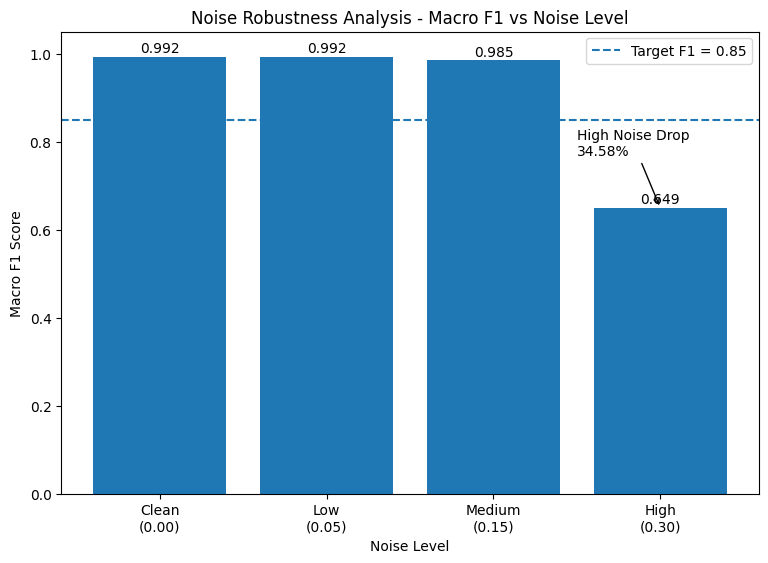

In [31]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    chart_data["Noise Label"],
    chart_data["Macro F1"]
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.axhline(
    y=0.85,
    linestyle="--",
    label="Target F1 = 0.85"
)

plt.xlabel("Noise Level")
plt.ylabel("Macro F1 Score")
plt.title("Noise Robustness Analysis - Macro F1 vs Noise Level")

plt.ylim(0, 1.05)

plt.annotate(
    f"High Noise Drop\n{high_drop_pct:.2f}%",
    xy=("High\n(0.30)", high_macro_f1),
    xytext=(2.5, high_macro_f1 + 0.12),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)
plt.legend()

print("Chart saved as outputs/noise_robustness.png")

plt.show()

## Noise Robustness Chart Analysis

The bar chart visualizes Macro F1 performance across clean, low, medium, and high Gaussian noise conditions.

A horizontal reference line at F1 = 0.85 is added to compare model performance against the target KPI. The annotation on the high-noise bar highlights the maximum observed performance drop.

This visualization helps determine whether the model remains reliable under noisy IoT sensor readings and whether it is suitable for real-world deployment.